# 1. Метод Якоби и Ричардсона

Решаем СЛАУ

Ax=b

### Метод Якоби

Разложение:

𝐴=𝐷+(𝐿+𝑈)

Итерация:

$$x^{k+1}=D^{-1}(b-(L+U)x^k)$$

Сходимость:
$$\rho(D^-{1}(L+U))$$
### Метод Ричардсона

Итерация:
$$x^{k+1}=x^k+\tau(b-Ax^k)$$

где 𝜏>0 — итерационный параметр.

Для симметричной положительно определённой матрицы:
$$0<\tau<\frac{2}{\lambda_{max}(A)}$$
	​

#### Предобуславливание

Решаем эквивалентную систему:

$$M^{-1}Ax=M^{-1}b$$

Простейший предобуславливатель:

𝑀=diag⁡(𝐴)

In [5]:
import numpy as np
import numpy.linalg as la

In [6]:
#Метод Якоби
def jacobi(A, b, x0=None, tol=1e-8, max_iter=1000):
    n = A.shape[0]
    if x0 is None:
        x = np.zeros(n)
    else:
        x = x0.copy()
        
    D = np.diag(A)
    R = A - np.diagflat(D)
    
    residuals = []
    
    for k in range(max_iter):
        x_new = (b - R @ x) / D
        r = la.norm(A @ x_new - b)
        residuals.append(r)
        
        if r < tol:
            break
        x = x_new
        
    return x, np.array(residuals)


In [7]:
#Метод Ричардсона
def richardson(A, b, tau, x0=None, tol=1e-8, max_iter=1000):
    n = A.shape[0]
    if x0 is None:
        x = np.zeros(n)
    else:
        x = x0.copy()
        
    residuals = []
    
    for k in range(max_iter):
        r = b - A @ x
        x = x + tau * r
        res = la.norm(r)
        residuals.append(res)
        
        if res < tol:
            break
            
    return x, np.array(residuals)


In [8]:
#Метод Ричардсона c предобуславливаемнием
def richardson_precond(A, b, tau, M_inv, x0=None, tol=1e-8, max_iter=1000):
    n = A.shape[0]
    if x0 is None:
        x = np.zeros(n)
    else:
        x = x0.copy()
        
    residuals = []
    
    for k in range(max_iter):
        r = b - A @ x
        x = x + tau * (M_inv @ r)
        res = la.norm(r)
        residuals.append(res)
        
        if res < tol:
            break
            
    return x, np.array(residuals)


3. Тесты: зависимость сходимости от обусловленности
Генерация SPD-матрицы с заданным числом обусловленности

In [9]:
def generate_spd(n, cond):
    Q, _ = la.qr(np.random.randn(n, n))
    eigs = np.linspace(1, cond, n)
    A = Q @ np.diag(eigs) @ Q.T
    return A


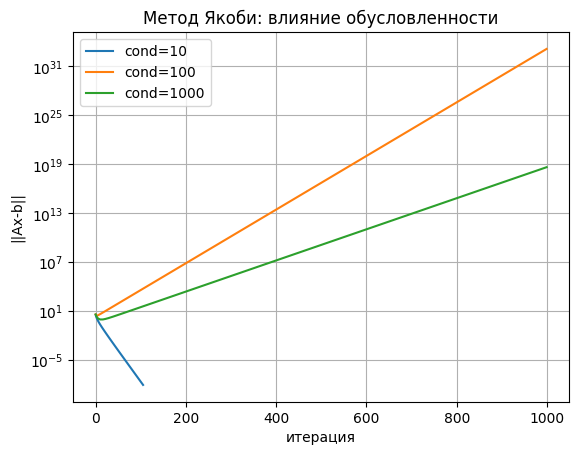

In [10]:
import matplotlib.pyplot as plt

n = 50
conds = [10, 100, 1000]

plt.figure()
for c in conds:
    A = generate_spd(n, c)
    b = np.ones(n)
    _, res = jacobi(A, b)
    plt.semilogy(res, label=f"cond={c}")

plt.xlabel("итерация")
plt.ylabel("||Ax-b||")
plt.legend()
plt.title("Метод Якоби: влияние обусловленности")
plt.grid()
plt.show()


видно что при росте числа обусловленности сходимость резко замедляется.

4. Влияние параметра τ в методе Ричардсона

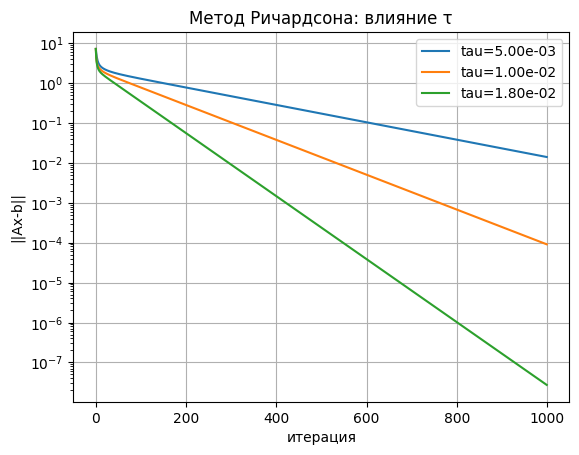

In [11]:
A = generate_spd(50, 100)
b = np.ones(50)

lmax = max(la.eigvals(A).real)

taus = [0.5/lmax, 1/lmax, 1.8/lmax]

plt.figure()
for tau in taus:
    _, res = richardson(A, b, tau)
    plt.semilogy(res, label=f"tau={tau:.2e}")

plt.xlabel("итерация")
plt.ylabel("||Ax-b||")
plt.legend()
plt.title("Метод Ричардсона: влияние τ")
plt.grid()
plt.show()


малое τ → медленная сходимость

оптимальное τ → быстрая

слишком большое τ → расходимость

5. Влияние предобуславливания

/mnt/windows/media/programs/.linuxvenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2792: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/tmp/ipykernel_7134/1722328764.py:12: RuntimeWarning: overflow encountered in matmul
  r = b - A @ x
/tmp/ipykernel_7134/1722328764.py:12: RuntimeWarning: invalid value encountered in matmul
  r = b - A @ x


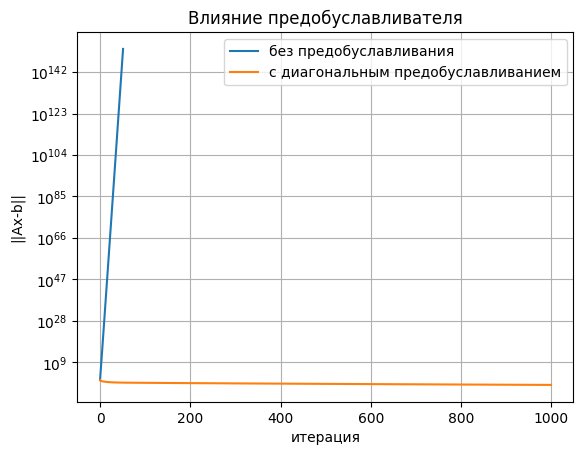

In [12]:
A = generate_spd(50, 1000)
b = np.ones(50)

D_inv = np.diag(1 / np.diag(A))
tau = 1.0

_, res_no = richardson(A, b, tau)
_, res_pre = richardson_precond(A, b, tau, D_inv)

plt.figure()
plt.semilogy(res_no, label="без предобуславливания")
plt.semilogy(res_pre, label="с диагональным предобуславливанием")
plt.xlabel("итерация")
plt.ylabel("||Ax-b||")
plt.legend()
plt.title("Влияние предобуславливателя")
plt.grid()
plt.show()


Вывод:
диагональный предобуславливатель существенно ускоряет сходимость.

Скорость сходимости итерационных методов ухудшается при росте числа обусловленности матрицы.

Метод Ричардсона чувствителен к выбору итерационного параметра τ.

Использование предобуславливания улучшает спектральные свойства системы и ускоряет сходимость.

# 2. МНК с Тихоновской региляризацией

Рассматривается переопределённая система

$$Ax \approx b, A \in \Re^{m \times n}, m \ge n$$
Классический МНК

Решение задачи

$min||Ax-b||^2_2$


задаётся нормальными уравнениями:
$$A^T Ax=A^T b$$

Тихоновская регуляризация

Рассматривается задача:
$$min(||Ax-b||^2_2+\lambda||x||^2_2)$$

Параметр 𝜆>0 — параметр регуляризации.

Решение:

регуляризация улучшает обусловленность задачи, но вносит смещение в решение.

In [13]:
import numpy as np
import numpy.linalg as la


In [14]:
#Обычный МНК
def least_squares(A, b):
    return la.solve(A.T @ A, A.T @ b)


In [15]:
#МНК с тихоновской регуляризацией
def tikhonov(A, b, lam):
    n = A.shape[1]
    return la.solve(A.T @ A + lam * np.eye(n), A.T @ b)


Тестовая задача (плохо обусловленная)
Генерация плохо обусловленной матрицы

In [16]:
def generate_ill_conditioned(m, n, cond):
    U, _ = la.qr(np.random.randn(m, n))
    V, _ = la.qr(np.random.randn(n, n))
    s = np.logspace(0, -np.log10(cond), n)
    A = U @ np.diag(s) @ V.T
    return A


Истинное решение + шум

In [17]:
np.random.seed(0)

m, n = 100, 20
A = generate_ill_conditioned(m, n, cond=1e6)

x_true = np.random.randn(n)
b_exact = A @ x_true

noise = 1e-2 * np.random.randn(m)
b = b_exact + noise


Влияние регуляризации на решение
Ошибка решения и норма решения

In [18]:
lambdas = np.logspace(-8, 0, 15)

err = []
norms = []

for lam in lambdas:
    x_reg = tikhonov(A, b, lam)
    err.append(la.norm(x_reg - x_true))
    norms.append(la.norm(x_reg))

x_ls = least_squares(A, b)
err_ls = la.norm(x_ls - x_true)
norm_ls = la.norm(x_ls)


График зависимости от λ

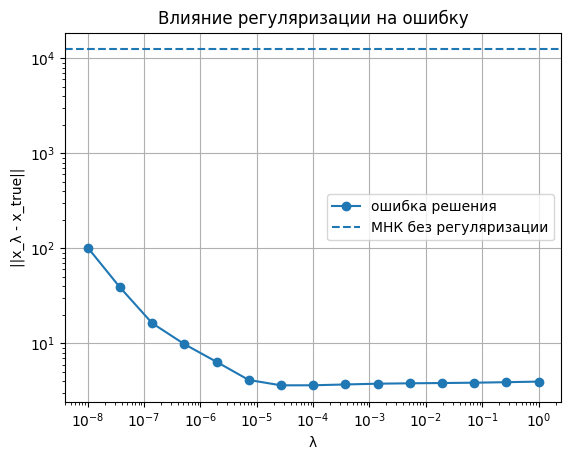

In [ ]:
import
 matplotlib.pyplot as plt

plt.figure()
plt.loglog(lambdas, err, marker='o', label="ошибка решения")
plt.axhline(err_ls, linestyle='--', label="МНК без регуляризации")
plt.xlabel("λ")
plt.ylabel("||x_λ - x_true||")
plt.legend()
plt.grid()
plt.title("Влияние регуляризации на ошибку")
plt.show()


L-кривая (классика для Тихонова)

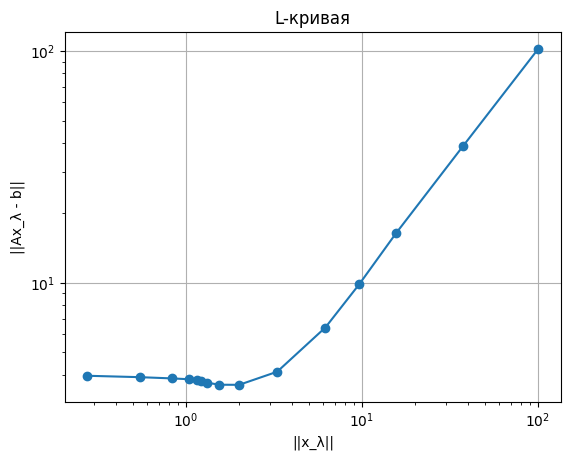

In [20]:
plt.figure()
plt.loglog(norms, err, marker='o')
plt.xlabel("||x_λ||")
plt.ylabel("||Ax_λ - b||")
plt.title("L-кривая")
plt.grid()
plt.show()


Анализ обусловленности

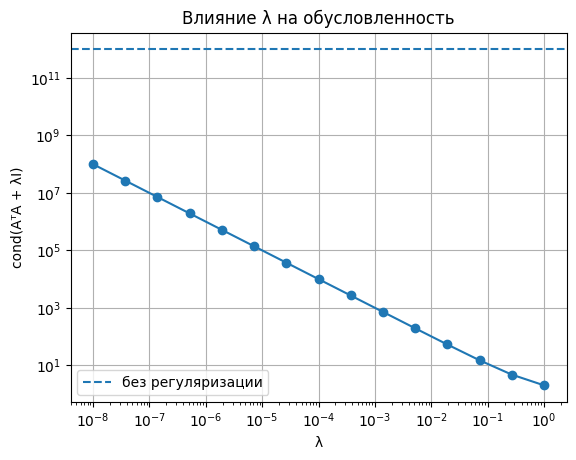

In [21]:
cond_no_reg = la.cond(A.T @ A)

conds_reg = []
for lam in lambdas:
    conds_reg.append(la.cond(A.T @ A + lam * np.eye(n)))

plt.figure()
plt.loglog(lambdas, conds_reg, marker='o')
plt.axhline(cond_no_reg, linestyle='--', label="без регуляризации")
plt.xlabel("λ")
plt.ylabel("cond(AᵀA + λI)")
plt.legend()
plt.grid()
plt.title("Влияние λ на обусловленность")
plt.show()


Без регуляризации решение МНК чувствительно к шуму из-за плохой обусловленности матрицы $A^T A$

Добавление тихоновской регуляризации уменьшает число обусловленности задачи.

При малых 𝜆 решение близко к классическому МНК, но неустойчиво.

При больших 𝜆 решение становится устойчивым, но сильно сглаженным.

Существует оптимальный диапазон 𝜆, обеспечивающий компромисс между точностью и устойчивостью.

# 3. Полиномиальная интерполяция в форме Лагранжа
Рассматривается интерполяция функции
$$f(x)=\frac{1}{1+25 x^2}, x \in[-5,5]$$
Полином Лагранжа

По узлам $x_0,...,x_n$:


$P_n(x)=\sum^n_{k=0} f(x_k)l_k(x), l_k(x)=\prod_{j\neq k}\frac{x-x_j}{x_k-x_j}$

Узлы интерполяции

Равномерная сетка:
$$x_k=a+k\frac{b-a}{n}, k=0,...,n$$

Узлы Чебышева:
$$x_k=\frac{a+b}{2}+\frac{b-a}{2}cos\frac{2k+1}{2(n+1)}\pi$$
 Узлы Чебышева уменьшают эффект Рунге и обеспечивают равномерную сходимость.

In [22]:
import numpy as np

#Функция
def f(x):
    return 1 / (1 + 25 * x**2)

#Узлы
def uniform_nodes(a, b, n):
    return np.linspace(a, b, n+1)

def chebyshev_nodes(a, b, n):
    k = np.arange(n+1)
    return (a+b)/2 + (b-a)/2 * np.cos((2*k+1)/(2*(n+1)) * np.pi)

#Лагранж
def lagrange_poly(x, nodes, values):
    x = np.array(x, dtype=float)
    P = np.zeros_like(x)
    
    n = len(nodes)
    for k in range(n):
        lk = np.ones_like(x)
        for j in range(n):
            if j != k:
                lk *= (x - nodes[j]) / (nodes[k] - nodes[j])
        P += values[k] * lk
        
    return P


Исследование с ростом числа узлов

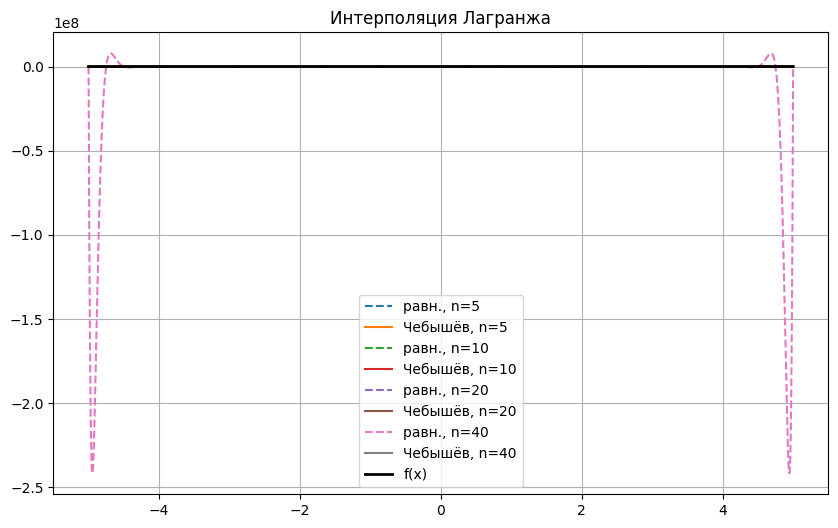

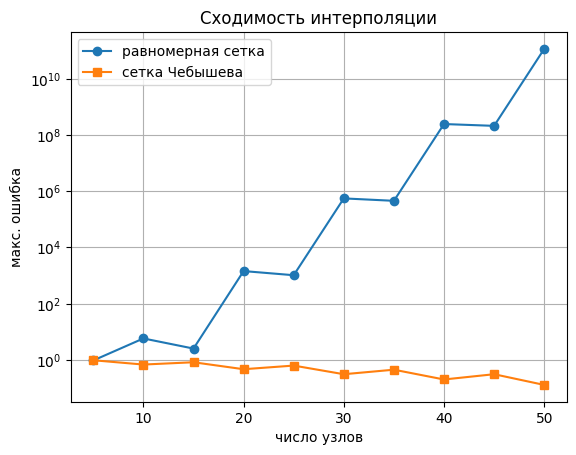

In [23]:
import matplotlib.pyplot as plt
#Тестовая сетка
a, b = -5, 5
x_plot = np.linspace(a, b, 2000)
y_true = f(x_plot)


#Сравнение равномерной и Чебышёвской сетки
Ns = [5, 10, 20, 40]

plt.figure(figsize=(10, 6))

for n in Ns:
    nodes_u = uniform_nodes(a, b, n)
    nodes_c = chebyshev_nodes(a, b, n)
    
    y_u = lagrange_poly(x_plot, nodes_u, f(nodes_u))
    y_c = lagrange_poly(x_plot, nodes_c, f(nodes_c))
    
    plt.plot(x_plot, y_u, '--', label=f"равн., n={n}")
    plt.plot(x_plot, y_c, '-', label=f"Чебышёв, n={n}")

plt.plot(x_plot, y_true, 'k', linewidth=2, label="f(x)")
plt.legend()
plt.title("Интерполяция Лагранжа")
plt.grid()
plt.show()

#Ошибка интерполяции
#Максимальная ошибка

err_uniform = []
err_cheb = []

Ns = range(5, 51, 5)

for n in Ns:
    nodes_u = uniform_nodes(a, b, n)
    nodes_c = chebyshev_nodes(a, b, n)
    
    Pu = lagrange_poly(x_plot, nodes_u, f(nodes_u))
    Pc = lagrange_poly(x_plot, nodes_c, f(nodes_c))
    
    err_uniform.append(np.max(np.abs(Pu - y_true)))
    err_cheb.append(np.max(np.abs(Pc - y_true)))

#График ошибки
plt.figure()
plt.semilogy(Ns, err_uniform, 'o-', label="равномерная сетка")
plt.semilogy(Ns, err_cheb, 's-', label="сетка Чебышева")
plt.xlabel("число узлов")
plt.ylabel("макс. ошибка")
plt.legend()
plt.grid()
plt.title("Сходимость интерполяции")
plt.show()





Равномерная сетка

при увеличении числа узлов ошибка не убывает;

на краях отрезка появляются сильные осцилляции;

проявляется эффект Рунге;

Узлы Чебышева

ошибка монотонно убывает;
аппроксимация равномерна по всему отрезку;

достигается спектральная сходимость;

# 4. Сплайн-интерполяция кубическими сплайнами

Пусть задана функция в узлах 
$$x_0<x_1<...<x_n \text{, } y_i=f(x_i)$$

Кубический сплайн дефекта 1 — это кусочно-кубическая функция 𝑆(𝑥), такая что:

$S(x_i)=y_i$

$S'(x), S''(x) \text{непрерывнц на }[x_0, x_n]$

$S''(x)$ — кусочно-линейная функция

Граничные условия:
$$M_0=S''(x_0)=0\text{, }M_n=S''(x_n)=0$$

Здесь $M_i=S''(x_i)$ — моменты сплайна.

2. СЛАУ на моменты

Для внутренних узлов 𝑖=1,…,𝑛−1:

$$h_{i-1}M_{i-1}+2(h_{i-1}+h_i)M_i+h_i M_{i+1}=6(\frac{y_{i+1}-y_i}{h_i}-\frac{y_i-y_{i-1}}{h_{i-1}})$$
где
$$h_i=x_{i+1}-x_i$$

Матрица — трёхдиагональная, решаем методом прогонки (TDMA).

In [24]:
import numpy as np

def thomas_algorithm(a, b, c, d):
    """
    Решает трёхдиагональную СЛАУ:
    a[i] x[i-1] + b[i] x[i] + c[i] x[i+1] = d[i]
    """
    n = len(d)
    cp = np.zeros(n)
    dp = np.zeros(n)
    
    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]
    
    for i in range(1, n):
        denom = b[i] - a[i] * cp[i-1]
        cp[i] = c[i] / denom if i < n-1 else 0
        dp[i] = (d[i] - a[i] * dp[i-1]) / denom
        
    x = np.zeros(n)
    x[-1] = dp[-1]
    
    for i in reversed(range(n-1)):
        x[i] = dp[i] - cp[i] * x[i+1]
        
    return x



#Построение кубического сплайна
def cubic_spline(x, y):
    n = len(x) - 1
    h = np.diff(x)
    
    # коэффициенты СЛАУ
    a = np.zeros(n-1)
    b = np.zeros(n-1)
    c = np.zeros(n-1)
    d = np.zeros(n-1)
    
    for i in range(1, n):
        a[i-1] = h[i-1]
        b[i-1] = 2 * (h[i-1] + h[i])
        c[i-1] = h[i]
        d[i-1] = 6 * (
            (y[i+1] - y[i]) / h[i] -
            (y[i] - y[i-1]) / h[i-1]
        )
    
    # моменты
    M = np.zeros(n+1)
    M[1:n] = thomas_algorithm(a, b, c, d)
    
    return M

#Вычисление сплайна в точке


def spline_eval(x_eval, x, y, M):
    x_eval = np.array(x_eval)
    S = np.zeros_like(x_eval)
    
    for k, xv in enumerate(x_eval):
        i = np.searchsorted(x, xv) - 1
        i = max(0, min(i, len(x)-2))
        
        h = x[i+1] - x[i]
        
        S[k] = (
            M[i] * (x[i+1] - xv)**3 / (6*h) +
            M[i+1] * (xv - x[i])**3 / (6*h) +
            (y[i] - M[i]*h*h/6) * (x[i+1] - xv) / h +
            (y[i+1] - M[i+1]*h*h/6) * (xv - x[i]) / h
        )
        
    return S




Тестирование

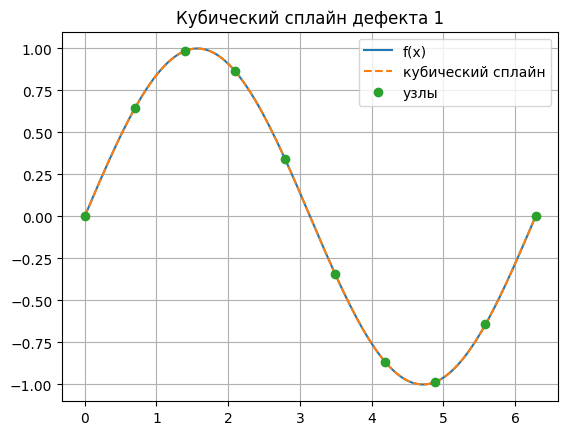

In [25]:
def f(x):
    return np.sin(x)
import matplotlib.pyplot as plt

x_nodes = np.linspace(0, 2*np.pi, 10)
y_nodes = f(x_nodes)

M = cubic_spline(x_nodes, y_nodes)

x_plot = np.linspace(0, 2*np.pi, 500)
y_spline = spline_eval(x_plot, x_nodes, y_nodes, M)

plt.figure()
plt.plot(x_plot, f(x_plot), label="f(x)")
plt.plot(x_plot, y_spline, '--', label="кубический сплайн")
plt.plot(x_nodes, y_nodes, 'o', label="узлы")
plt.legend()
plt.grid()
plt.title("Кубический сплайн дефекта 1")
plt.show()



Кубический сплайн дефекта 1 обеспечивает непрерывность функции и её первых двух производных.

Задача построения сплайна сводится к решению трёхдиагональной СЛАУ на моменты.

Метод прогонки позволяет эффективно решать такую систему за линейное время.

Сплайн-интерполяция обеспечивает более устойчивую аппроксимацию по сравнению с полиномиальной интерполяцией высокой степени.

# 5. Метод трапеции и Симпсона для интегрирования

Рассматривается вычисление интеграла
​
$$I= \int_a^b f(x)dx$$

Метод  трапеций

$$I_h=h(\frac{f(x_0)}{2}+\sum^{n-1}_{k=1}f(x_k)+\frac{f(x_n)}{2})$$

Теоретический порядок точности:

𝑝=2

Метод Симпсона

(требует чётного числа интервалов)

$$I_h=\frac{h}{3}(f(x_0)+4\sum f(x_{2k-1})+2\sum f(x_{2k})+f(x_n))$$

Теоретический порядок:

𝑝=4

In [28]:
import numpy as np

#Метод трапеций

def trapezoidal(f, a, b, n):
    x = np.linspace(a, b, n+1)
    h = (b - a) / n
    return h * (0.5*f(x[0]) + f(x[1:-1]).sum() + 0.5*f(x[-1]))

#Метод Симпсона
def simpson(f, a, b, n):
    if n % 2 != 0:
        raise ValueError("n должно быть чётным")
    x = np.linspace(a, b, n+1)
    h = (b - a) / n
    return h/3 * (
        f(x[0]) +
        4 * f(x[1:-1:2]).sum() +
        2 * f(x[2:-2:2]).sum() +
        f(x[-1])
    )


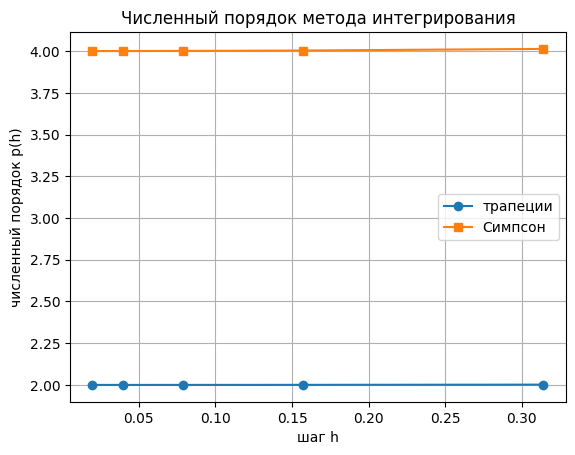

In [29]:
# Шаги
a, b = 0, np.pi
Ns = np.array([10, 20, 40, 80, 160, 320])
h = (b - a) / Ns



#Тестовая функция

'''Выбираем гладкую функцию, чтобы увидеть 
теоретический порядок.'''
def f(x):
    return np.sin(x)

I_exact = 2.0

# Вычисляем ошибки
err_trap = np.array([abs(trapezoidal(f, a, b, n) - I_exact) for n in Ns])
err_simp = np.array([abs(simpson(f, a, b, n) - I_exact) for n in Ns if n % 2 == 0])

# Численный порядок сходимости
p_trap = np.log(err_trap[:-1] / err_trap[1:]) / np.log(2)
p_simp = np.log(err_simp[:-1] / err_simp[1:]) / np.log(2)

# График порядка метода
plt.figure()
plt.plot(h[:-1], p_trap, 'o-', label="трапеции")
plt.plot(h[:len(p_simp)], p_simp, 's-', label="Симпсон")
plt.xlabel("шаг h")
plt.ylabel("численный порядок p(h)")
plt.grid(True)
plt.legend()
plt.title("Численный порядок метода интегрирования")
plt.show()